# Tugas Besar 1 IF3270 — Feed-Forward Neural Network
Dataset: Global Student Placement (`datasetml_2026.csv`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

from src.models.ffnn import FFNN
from src.optim.gradient_descent import SGD
from src.optim.adam import Adam
from src.optim.loss import bce_loss
from src.train import train
from src.utils.preprocessing import load_and_preprocess, accuracy
from src.utils.visualization import plot_history, compare_histories, bar_comparison

np.random.seed(42)

In [2]:
DATA_PATH = '../data/datasetml_2026.csv'
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = load_and_preprocess(DATA_PATH)

N_FEATURES = X_train.shape[1]
BASE_SIZES = [N_FEATURES, 64, 32, 1]
EPOCHS, BS, LR = 100, 64, 0.001

print(f'Features : {N_FEATURES}')
print(f'Train    : {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')

Features : 24
Train    : 7000  Val: 1500  Test: 1500


---
## Eksperimen 1: Depth & Width Analysis

narrow  [16,8]  test_acc=0.7647
medium  [64,32]  test_acc=0.7193
wide  [256,128]  test_acc=0.6780


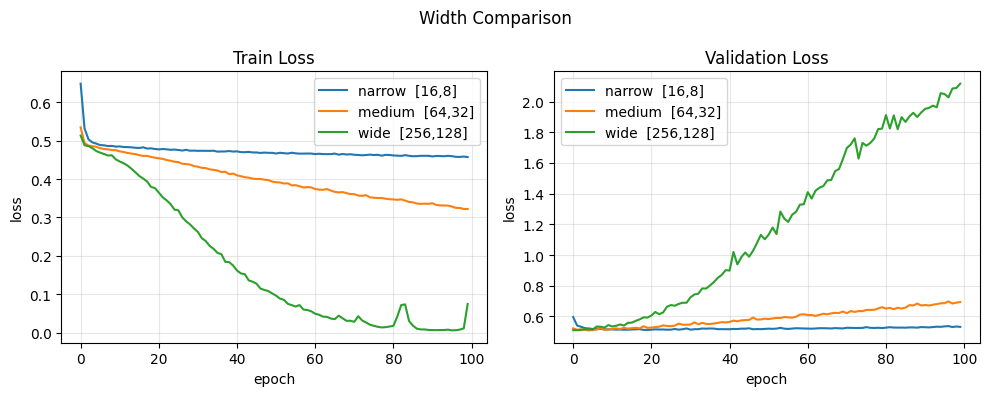

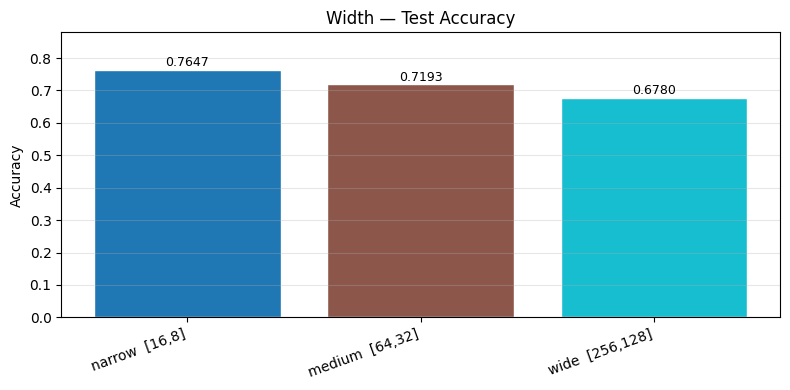

In [3]:
# 1a — width (depth fixed: 2 hidden layers)
width_configs = {
    'narrow  [16,8]':  [N_FEATURES, 16, 8, 1],
    'medium  [64,32]': [N_FEATURES, 64, 32, 1],
    'wide  [256,128]': [N_FEATURES, 256, 128, 1],
}
width_histories, width_accs = {}, {}

for name, sizes in width_configs.items():
    model = FFNN(sizes, ['relu'] * (len(sizes) - 2) + ['sigmoid'])
    opt   = Adam(model.parameters(), learning_rate=LR)
    hist  = train(model, X_train, y_train, opt, bce_loss,
                  epochs=EPOCHS, batch_size=BS, X_val=X_val, y_val=y_val, verbose=0)
    acc   = accuracy(model.predict(X_test), y_test)
    width_histories[name], width_accs[name] = hist, acc
    print(f'{name}  test_acc={acc:.4f}')

compare_histories(list(width_histories.values()), list(width_histories.keys()), title='Width Comparison')
bar_comparison(list(width_accs.keys()), list(width_accs.values()), title='Width — Test Accuracy')

shallow [64]  test_acc=0.7553
medium  [64,32]  test_acc=0.7227
deep    [64,32,16,8]  test_acc=0.6920


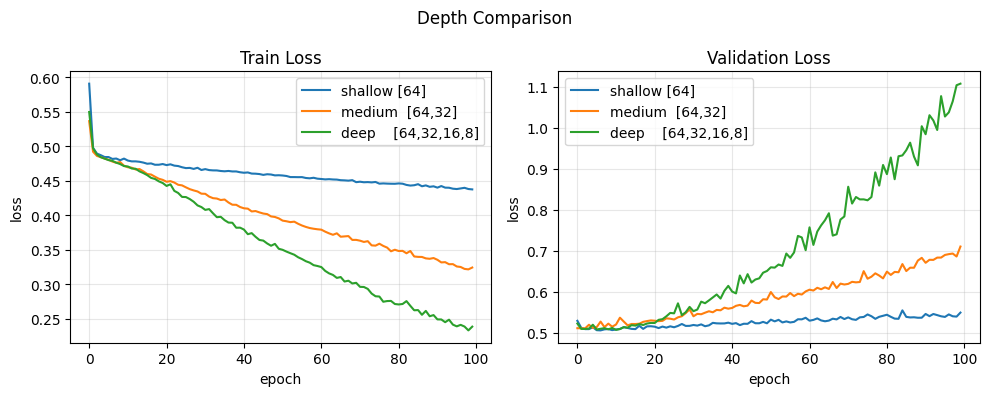

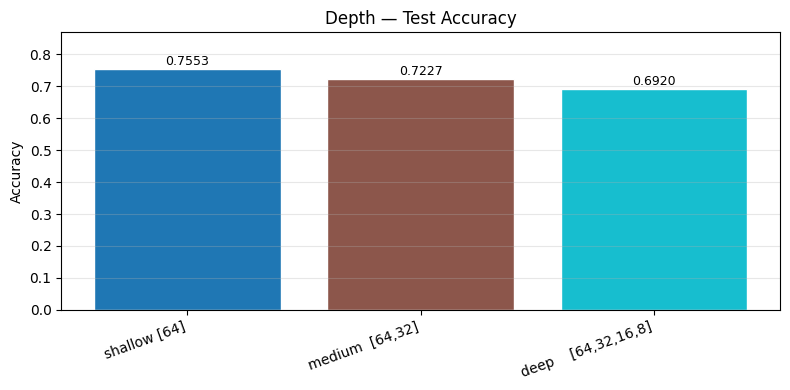

In [4]:
# 1b — depth (width fixed: 64 units)
depth_configs = {
    'shallow [64]':         [N_FEATURES, 64, 1],
    'medium  [64,32]':      [N_FEATURES, 64, 32, 1],
    'deep    [64,32,16,8]': [N_FEATURES, 64, 32, 16, 8, 1],
}
depth_histories, depth_accs = {}, {}

for name, sizes in depth_configs.items():
    model = FFNN(sizes, ['relu'] * (len(sizes) - 2) + ['sigmoid'])
    opt   = Adam(model.parameters(), learning_rate=LR)
    hist  = train(model, X_train, y_train, opt, bce_loss,
                  epochs=EPOCHS, batch_size=BS, X_val=X_val, y_val=y_val, verbose=0)
    acc   = accuracy(model.predict(X_test), y_test)
    depth_histories[name], depth_accs[name] = hist, acc
    print(f'{name}  test_acc={acc:.4f}')

compare_histories(list(depth_histories.values()), list(depth_histories.keys()), title='Depth Comparison')
bar_comparison(list(depth_accs.keys()), list(depth_accs.values()), title='Depth — Test Accuracy')

---
## Eksperimen 2: Activation Function Comparison

linear        test_acc=0.7673
relu          test_acc=0.7247
sigmoid       test_acc=0.7667
tanh          test_acc=0.7300
elu           test_acc=0.7467
leaky_relu    test_acc=0.7173


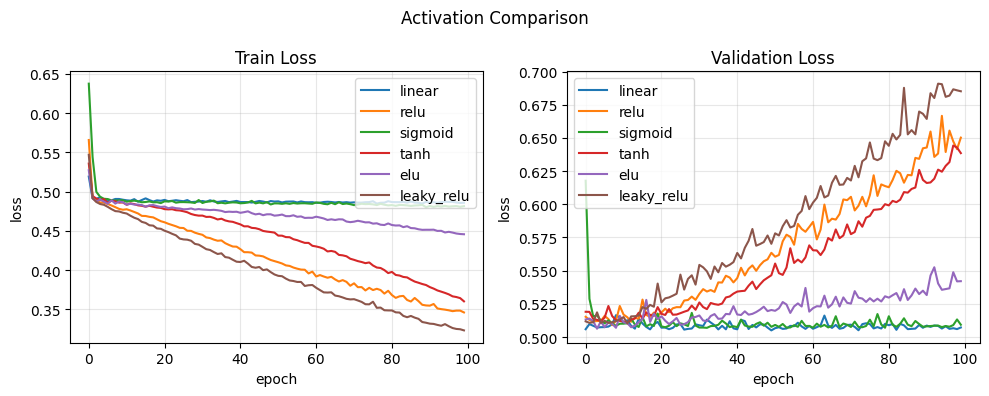

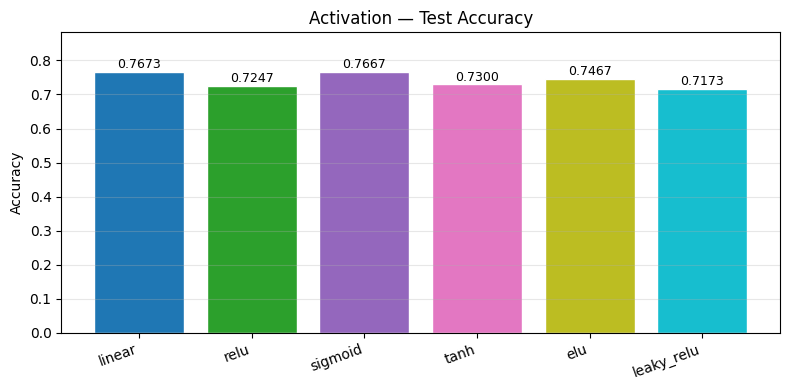

In [5]:
act_configs  = ['linear', 'relu', 'sigmoid', 'tanh', 'elu', 'leaky_relu']
act_histories, act_accs = {}, {}

for act in act_configs:
    model = FFNN(BASE_SIZES, [act, act, 'sigmoid'])
    opt   = Adam(model.parameters(), learning_rate=LR)
    hist  = train(model, X_train, y_train, opt, bce_loss,
                  epochs=EPOCHS, batch_size=BS, X_val=X_val, y_val=y_val, verbose=0)
    acc   = accuracy(model.predict(X_test), y_test)
    act_histories[act], act_accs[act] = hist, acc
    print(f'{act:12s}  test_acc={acc:.4f}')

compare_histories(list(act_histories.values()), list(act_histories.keys()), title='Activation Comparison')
bar_comparison(list(act_accs.keys()), list(act_accs.values()), title='Activation — Test Accuracy')

---
## Eksperimen 3: Learning Rate Comparison (SGD)

lr=0.1  test_acc=0.7380
lr=0.01  test_acc=0.7693
lr=0.001  test_acc=0.7580


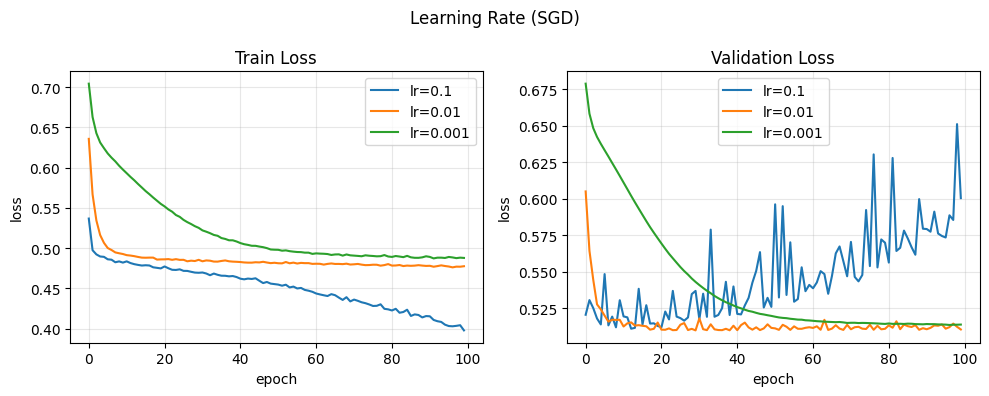

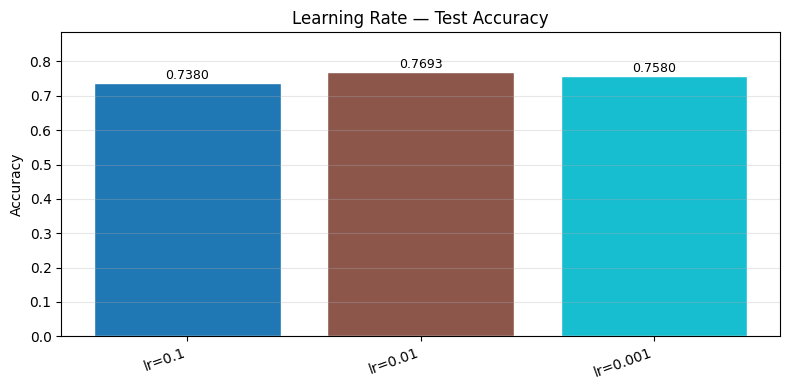

In [6]:
lr_configs = [0.1, 0.01, 0.001]
lr_histories, lr_accs = {}, {}

for lr in lr_configs:
    model = FFNN(BASE_SIZES, ['relu', 'relu', 'sigmoid'])
    opt   = SGD(model.parameters(), learning_rate=lr)
    hist  = train(model, X_train, y_train, opt, bce_loss,
                  epochs=EPOCHS, batch_size=BS, X_val=X_val, y_val=y_val, verbose=0)
    acc   = accuracy(model.predict(X_test), y_test)
    lr_histories[f'lr={lr}'], lr_accs[f'lr={lr}'] = hist, acc
    print(f'lr={lr}  test_acc={acc:.4f}')

compare_histories(list(lr_histories.values()), list(lr_histories.keys()), title='Learning Rate (SGD)')
bar_comparison(list(lr_accs.keys()), list(lr_accs.values()), title='Learning Rate — Test Accuracy')

---
## Eksperimen 4: Regularization

none          test_acc=0.7200
L1=0.001      test_acc=0.7667
L2=0.001      test_acc=0.7513


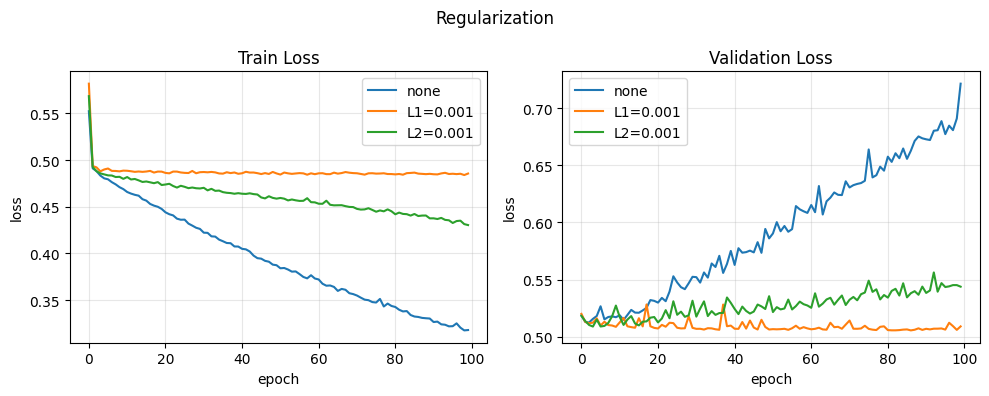

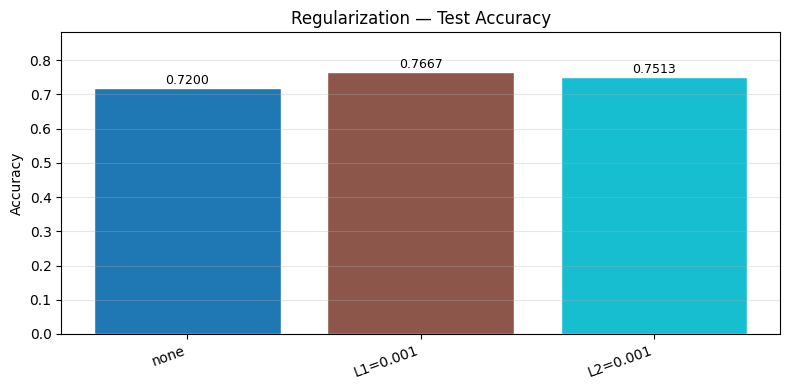

In [7]:
reg_configs = [
    ('none',     dict(l1_lambda=0.0,   l2_lambda=0.0)),
    ('L1=0.001', dict(l1_lambda=0.001, l2_lambda=0.0)),
    ('L2=0.001', dict(l1_lambda=0.0,   l2_lambda=0.001)),
]
reg_histories, reg_accs = {}, {}

for name, reg_kwargs in reg_configs:
    model = FFNN(BASE_SIZES, ['relu', 'relu', 'sigmoid'])
    opt   = Adam(model.parameters(), learning_rate=LR, **reg_kwargs)
    hist  = train(model, X_train, y_train, opt, bce_loss,
                  epochs=EPOCHS, batch_size=BS, X_val=X_val, y_val=y_val, verbose=0)
    acc   = accuracy(model.predict(X_test), y_test)
    reg_histories[name], reg_accs[name] = hist, acc
    print(f'{name:12s}  test_acc={acc:.4f}')

compare_histories(list(reg_histories.values()), list(reg_histories.keys()), title='Regularization')
bar_comparison(list(reg_accs.keys()), list(reg_accs.values()), title='Regularization — Test Accuracy')

---
## Eksperimen 5: Our FFNN vs sklearn MLPClassifier

Our FFNN    accuracy=0.7187  F1=0.7860
sklearn MLP accuracy=0.6980  F1=0.7561


c:\Users\Mahesa\OneDrive\ITB\Coding\College\Academic\IF\Smt-6\machine-learning\tugas\tugas-besar-1\feed-forward-neural-network\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


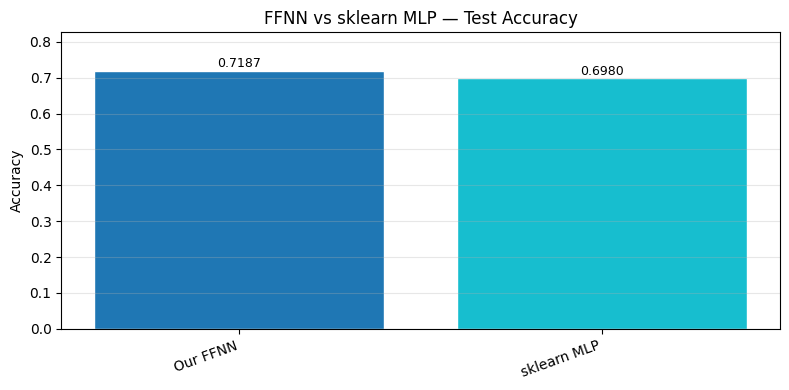

In [8]:
# our FFNN
model_ours = FFNN(BASE_SIZES, ['relu', 'relu', 'sigmoid'])
opt_ours   = Adam(model_ours.parameters(), learning_rate=LR)
train(model_ours, X_train, y_train, opt_ours, bce_loss,
      epochs=EPOCHS, batch_size=BS, verbose=0)
ours_pred = (model_ours.predict(X_test) >= 0.5).astype(int).flatten()
ours_acc  = accuracy_score(y_test.flatten(), ours_pred)
ours_f1   = f1_score(y_test.flatten(), ours_pred)

# sklearn MLP
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                    solver='adam', learning_rate_init=LR,
                    max_iter=EPOCHS, batch_size=BS, random_state=42)
mlp.fit(X_train, y_train.ravel())
sk_pred = mlp.predict(X_test)
sk_acc  = accuracy_score(y_test.flatten(), sk_pred)
sk_f1   = f1_score(y_test.flatten(), sk_pred)

print(f'Our FFNN    accuracy={ours_acc:.4f}  F1={ours_f1:.4f}')
print(f'sklearn MLP accuracy={sk_acc:.4f}  F1={sk_f1:.4f}')
bar_comparison(['Our FFNN', 'sklearn MLP'], [ours_acc, sk_acc],
               title='FFNN vs sklearn MLP — Test Accuracy')

---
## Eksperimen 6: RMSNorm Analysis (Bonus 10%)

without RMSNorm       test_acc=0.7233
with RMSNorm          test_acc=0.6080


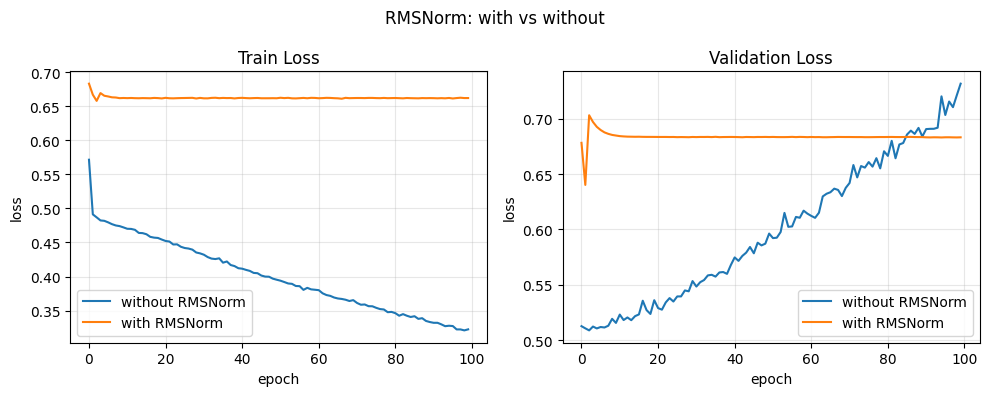

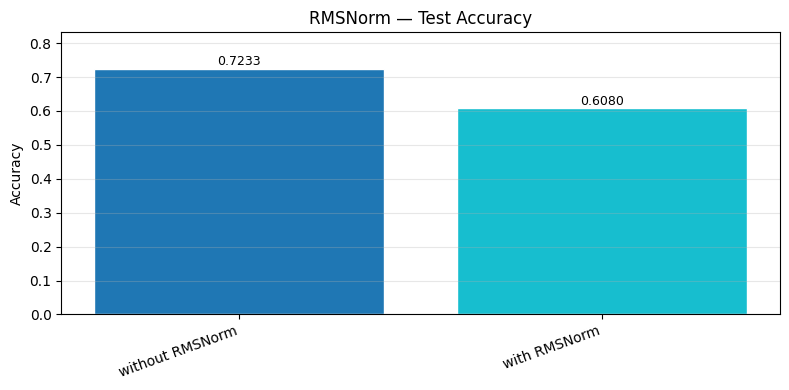

In [9]:
rms_configs = {'without RMSNorm': False, 'with RMSNorm': True}
rms_histories, rms_accs = {}, {}

for name, use_rms in rms_configs.items():
    model = FFNN(BASE_SIZES, ['relu', 'relu', 'sigmoid'], use_rmsnorm=use_rms)
    opt   = Adam(model.parameters(), learning_rate=LR)
    hist  = train(model, X_train, y_train, opt, bce_loss,
                  epochs=EPOCHS, batch_size=BS, X_val=X_val, y_val=y_val, verbose=0)
    acc   = accuracy(model.predict(X_test), y_test)
    rms_histories[name], rms_accs[name] = hist, acc
    print(f'{name:20s}  test_acc={acc:.4f}')

compare_histories(list(rms_histories.values()), list(rms_histories.keys()), title='RMSNorm: with vs without')
bar_comparison(list(rms_accs.keys()), list(rms_accs.values()), title='RMSNorm — Test Accuracy')

---
## Eksperimen 7: Adam vs SGD Convergence (Bonus 40%)

SGD  lr=0.01  test_acc=0.7680
Adam lr=0.001  test_acc=0.7247


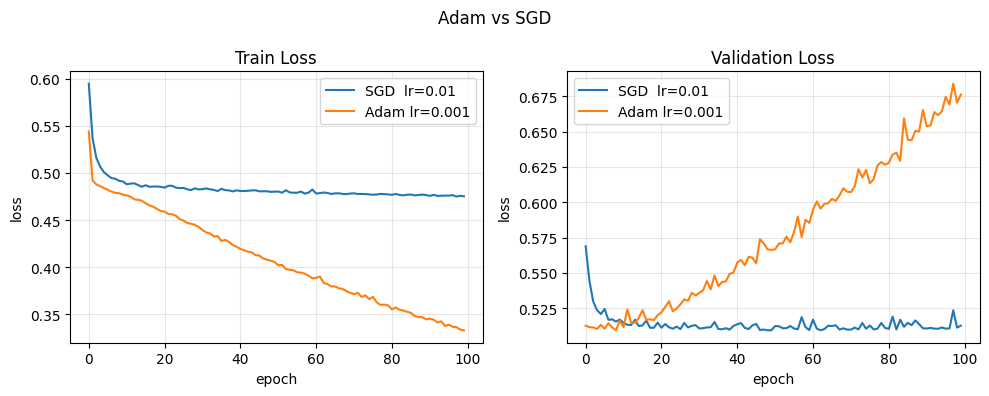

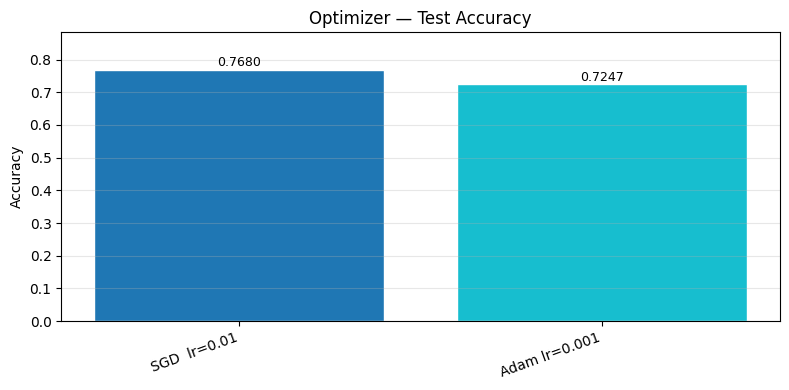

In [10]:
optim_configs = {
    'SGD  lr=0.01':  lambda p: SGD(p,  learning_rate=0.01),
    'Adam lr=0.001': lambda p: Adam(p, learning_rate=0.001),
}
optim_histories, optim_accs = {}, {}

for name, opt_fn in optim_configs.items():
    model = FFNN(BASE_SIZES, ['relu', 'relu', 'sigmoid'])
    hist  = train(model, X_train, y_train, opt_fn(model.parameters()), bce_loss,
                  epochs=EPOCHS, batch_size=BS, X_val=X_val, y_val=y_val, verbose=0)
    acc   = accuracy(model.predict(X_test), y_test)
    optim_histories[name], optim_accs[name] = hist, acc
    print(f'{name}  test_acc={acc:.4f}')

compare_histories(list(optim_histories.values()), list(optim_histories.keys()), title='Adam vs SGD')
bar_comparison(list(optim_accs.keys()), list(optim_accs.values()), title='Optimizer — Test Accuracy')

---
## Autograd Gradient Check

In [11]:
from src.engine.autodiff import Tensor

def numerical_grad(f, x, h=1e-5):
    grad = np.zeros_like(x)
    it   = np.nditer(x, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        xp, xm = x.copy(), x.copy()
        xp[idx] += h; xm[idx] -= h
        grad[idx] = (f(xp) - f(xm)) / (2 * h)
        it.iternext()
    return grad

np.random.seed(0)
x_np = np.random.randn(4, 3)
W_np = np.random.randn(3, 2)
b_np = np.random.randn(2)
y_np = np.random.rand(4, 2)

def f(W_flat):
    W   = W_flat.reshape(3, 2)
    out = x_np @ W + b_np
    return float(np.mean((out - y_np) ** 2))

x_t  = Tensor(x_np, requires_grad=False)
W_t  = Tensor(W_np)
b_t  = Tensor(b_np)
y_t  = Tensor(y_np, requires_grad=False)
loss = ((x_t @ W_t + b_t - y_t) ** 2).mean()
loss.backward()

num = numerical_grad(f, W_np.flatten())
err = np.max(np.abs(W_t.grad.flatten() - num))
print(f'Max gradient error on W: {err:.2e}  (expect < 1e-5)')

Max gradient error on W: 3.22e-11  (expect < 1e-5)


---
## Weight & Gradient Distribution

Epoch 1/100  loss=0.5570  val_loss=0.5235
Epoch 2/100  loss=0.4926  val_loss=0.5122
Epoch 3/100  loss=0.4877  val_loss=0.5110
Epoch 4/100  loss=0.4843  val_loss=0.5203
Epoch 5/100  loss=0.4821  val_loss=0.5160
Epoch 6/100  loss=0.4794  val_loss=0.5136
Epoch 7/100  loss=0.4793  val_loss=0.5136
Epoch 8/100  loss=0.4790  val_loss=0.5218
Epoch 9/100  loss=0.4766  val_loss=0.5176
Epoch 10/100  loss=0.4732  val_loss=0.5165
Epoch 11/100  loss=0.4734  val_loss=0.5201
Epoch 12/100  loss=0.4701  val_loss=0.5324
Epoch 13/100  loss=0.4694  val_loss=0.5261
Epoch 14/100  loss=0.4661  val_loss=0.5242
Epoch 15/100  loss=0.4641  val_loss=0.5297
Epoch 16/100  loss=0.4660  val_loss=0.5341
Epoch 17/100  loss=0.4614  val_loss=0.5397
Epoch 18/100  loss=0.4594  val_loss=0.5347
Epoch 19/100  loss=0.4588  val_loss=0.5373
Epoch 20/100  loss=0.4569  val_loss=0.5355
Epoch 21/100  loss=0.4548  val_loss=0.5369
Epoch 22/100  loss=0.4525  val_loss=0.5465
Epoch 23/100  loss=0.4519  val_loss=0.5439
Epoch 24/100  loss=0

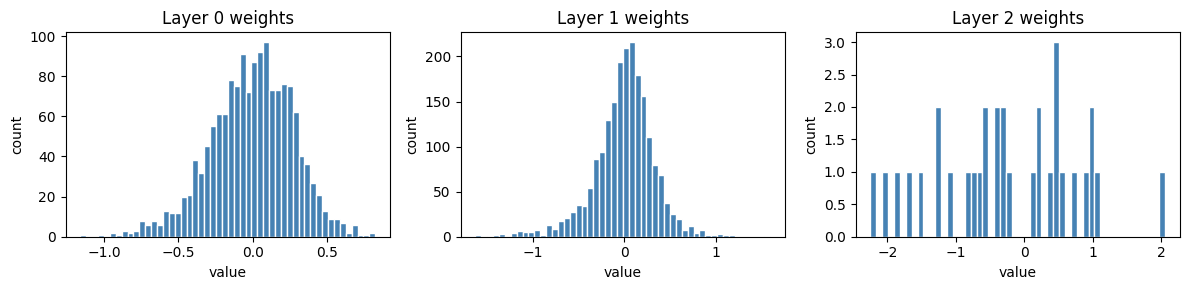

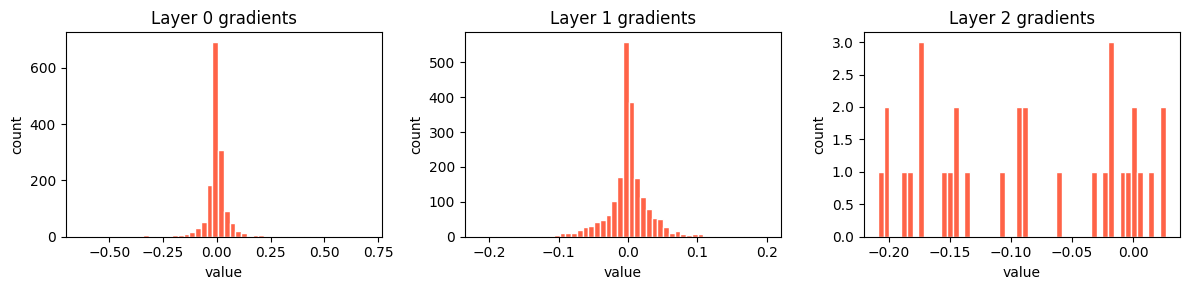

In [12]:
best = FFNN(BASE_SIZES, ['relu', 'relu', 'sigmoid'])
opt  = Adam(best.parameters(), learning_rate=LR)
train(best, X_train, y_train, opt, bce_loss,
      epochs=EPOCHS, batch_size=BS, X_val=X_val, y_val=y_val, verbose=1)

# one forward+backward to populate .grad
pred = best.forward(X_train[:BS])
bce_loss(pred, y_train[:BS]).backward()

best.plot_weight_distribution()
best.plot_gradient_distribution()